# 04 - Collaborative filtering vs content-based, end to end

**Two philosophies for "what should play next?", built and measured side by side.**

- **Collaborative filtering (CF)** recommends by *who listens with whom* - pure
  behaviour, nothing about the track itself (item-CF, ALS, track2vec).
- **Content-based** recommends by *what a track is like* - its feature vector,
  no behaviour at all (`content_knn`).

This notebook builds a synthetic Spotify-style corpus, writes item-CF **from
scratch** in ~20 lines and checks it against the library model, runs the whole
model zoo, then measures the punchline this project is candid about: **CF wins on
accuracy, content wins on coverage and the long tail.**

It is the executable companion to **[`THEORY.md`](../THEORY.md)** - each section
points at the theory section it demonstrates. Runs end to end on synthetic data
in a few minutes.

In [1]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from collections import defaultdict
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from playlistcont.data.schema import Dataset
from playlistcont.data.synthetic import make_synthetic
from playlistcont.challenge.scenarios import build_scenarios, train_test_split
from playlistcont.challenge.metrics import r_precision, evaluate_one, aggregate
from playlistcont.challenge.coverage import (bucketize_catalog, bucket_hit_rate,
                                             catalog_coverage)
from playlistcont.models.base import TrackIndex
from playlistcont.models.popularity import PopularityRecommender
from playlistcont.models.itemcf import ItemCFRecommender
from playlistcont.models.mf import ALSRecommender
from playlistcont.models.track2vec import Track2VecRecommender
from playlistcont.models.content_knn import ContentKNNRecommender
VIZ = os.path.join('..', 'visualizations'); os.makedirs(VIZ, exist_ok=True)
print('imports ready')

imports ready


## 1. Build a corpus and the held-out scenarios  ([THEORY.md §1](../THEORY.md#1-the-recommendation-problem-on-our-data))

The data is a binary **playlist x track** matrix. We split off held-out playlists
and expose each as a *seed* (some tracks) with the rest as the answer key - exactly
the challenge setup. A moderate corpus keeps the live model fits snappy; the
full-harness numbers later are loaded from the committed `results/` run.

In [2]:
ds = make_synthetic(n_playlists=4000, n_tracks=2500, seed=1)
train_pls, test_pls = train_test_split(ds, n_test=1200, seed=1)
train_ds = Dataset(playlists=train_pls, tracks=ds.tracks, features=ds.features)
cases = build_scenarios(test_pls, per_scenario=60, seed=1)
track_artist = ds.track_artist_map()
from collections import Counter
print(f'corpus: {ds.n_playlists} playlists x {ds.n_tracks} tracks')
print(f'{len(train_pls)} train / {len(test_pls)} test playlists -> {len(cases)} scenario cases')

def eval_model(model, scenario=None):
    """Mean R-precision of a model over all cases (or one scenario)."""
    rs = [r_precision(model.recommend(c.seed_tracks, c.title, k=500), c.holdout, track_artist)
          for c in cases if scenario is None or c.scenario == scenario]
    return float(np.mean(rs))

corpus: 4000 playlists x 2500 tracks
2800 train / 1200 test playlists -> 502 scenario cases


## 2. The popularity floor  ([THEORY.md §7](../THEORY.md#7-evaluation--and-why-offline-metrics-mislead))

Always recommend the globally most-played tracks. It uses no seed at all, so it is
the **floor** every real model must clear - and, as we'll see in section 5, it pays
for that accuracy with zero tail coverage.

In [3]:
pop = PopularityRecommender().fit(train_ds)
floor = eval_model(pop)
print(f'popularity floor: R-precision = {floor:.3f}')

popularity floor: R-precision = 0.167


## 3. Item-CF from scratch, in ~20 lines  ([THEORY.md §2](../THEORY.md#2-neighbourhood-collaborative-filtering))

The whole idea: **recommend tracks that co-occur with your seed**, discounting
popularity. Co-occurrence is $C = A^\top A$; cosine-normalize by $\sqrt{c_i c_j}$
(plus a little shrinkage so one lucky co-occurrence isn't a perfect match); score a
seed by summing its tracks' similarity rows. That's it - the same recipe as
`models/itemcf.py`, laid bare.

In [4]:
idx = TrackIndex(train_ds)          # gives us A = playlist x track (sparse) + popularity
A = idx.pt                          # (n_playlists, n_tracks) binary
pop_count = idx.track_pop           # c_i = column sums

co = (A.T @ A).tocoo()              # C = A^T A : track-track co-occurrence
r, c, v = co.row, co.col, co.data.astype(np.float64)
keep = r != c                       # drop the diagonal (a track with itself)
r, c, v = r[keep], c[keep], v[keep]
sim_vals = v / (np.sqrt(pop_count[r] * pop_count[c]) + 10.0)   # cosine + shrinkage
SIM = sp.csr_matrix((sim_vals, (r, c)), shape=co.shape)        # sparse track-track sim

def scratch_itemcf(seed_uris, k=500):
    seed_ids = [idx.uri_to_id[u] for u in seed_uris if u in idx.uri_to_id]
    scores = np.zeros(idx.n_tracks)
    for sid in seed_ids:                       # sum the seed tracks' similarity rows
        row = SIM.getrow(sid)
        scores[row.indices] += row.data
    scores[seed_ids] = -np.inf                 # never recommend a seed track
    top = np.argsort(-scores)[:k]
    return [idx.track_uris[i] for i in top]

print('built track-track similarity:', SIM.shape, 'with', SIM.nnz, 'nonzeros')

built track-track similarity: (2500, 2500) with 1263726 nonzeros


### Does the 20-line version match the library?

We compare our from-scratch top-100 against `ItemCFRecommender` on a sampled
scenario. They should agree on the large majority of tracks - the library adds
neighbour-truncation and a popularity backfill, but the core signal is identical.

In [5]:
lib_cf = ItemCFRecommender().fit(train_ds)
sample = [c for c in cases if c.scenario == 'title_10'][:20]
overlaps = []
for c in sample:
    a = set(scratch_itemcf(c.seed_tracks, k=100))
    b = set(lib_cf.recommend(c.seed_tracks, c.title, k=100))
    overlaps.append(len(a & b) / 100)
print(f'mean top-100 overlap with the library item-CF: {np.mean(overlaps):.0%}')
print(f'from-scratch R-precision (title_10): '
      f'{np.mean([r_precision(scratch_itemcf(c.seed_tracks), c.holdout, track_artist) for c in sample]):.3f}')

mean top-100 overlap with the library item-CF: 99%


from-scratch R-precision (title_10): 0.234


## 4. The model zoo: CF and content, side by side

Now the library models. Three are collaborative - **item-CF** (neighbourhoods,
[§2](../THEORY.md#2-neighbourhood-collaborative-filtering)), **ALS** (matrix
factorization, [§3](../THEORY.md#3-matrix-factorization-als)), **track2vec**
(embeddings, [§4](../THEORY.md#4-embeddings-track2vec--item2vec)) - and one is
content-based, **`content_knn`** (feature cosine,
[§5](../THEORY.md#5-content-based-recommendation)). All share one `recommend`
interface, so we can line them up directly.

In [6]:
t=time.time()
models = {
    'popularity':  pop,
    'item_cf':     lib_cf,
    'als':         ALSRecommender(factors=32, iterations=8).fit(train_ds),
    'track2vec':   Track2VecRecommender(epochs=3).fit(train_ds),
    'content_knn': ContentKNNRecommender().fit(train_ds),
}
print(f'fit {len(models)} models in {time.time()-t:.1f}s')

# comparison on three contrasting scenarios
scen = ['no_title_5', 'title_10', 'title_random_100']
tab = pd.DataFrame({name: {s: eval_model(m, s) for s in scen} for name, m in models.items()}).T
tab['OVERALL'] = {name: eval_model(m) for name, m in models.items()}
tab.round(3)

fit 5 models in 3.8s


,no_title_5,title_10,title_random_100,OVERALL
popularity,0.141,0.156,0.136,0.167
item_cf,0.355,0.266,0.552,0.342
als,0.344,0.287,0.548,0.342
track2vec,0.274,0.159,0.269,0.228
content_knn,0.127,0.069,0.320,0.126


Read the columns, not just the bottom line. Item-CF and ALS lead; `content_knn`
trails on accuracy and is weakest with a tiny seed (`no_title_5`) - a mean of five
feature vectors barely pins down a direction - but climbs sharply on the big
`title_random_100` seed, where the centroid finally has enough tracks to point
cleanly. This is the accuracy half of the story; section 5 is the other half.

## 5. Full-harness numbers (the committed 10-scenario run)  ([THEORY.md §7](../THEORY.md#7-evaluation--and-why-offline-metrics-mislead))

Our live corpus is small for speed. The authoritative comparison is the full
10,000-playlist / 10-scenario run committed to
[`results/results_content_knn.csv`](../results/results_content_knn.csv). Loading it
shows where content-based really sits.

In [7]:
res = pd.read_csv(os.path.join('..', 'results', 'results_content_knn.csv'))
overall = (res[res.scenario == 'OVERALL'].set_index('model')[['r_precision','ndcg','clicks']]
           .sort_values('r_precision', ascending=False).round(3))
print('OVERALL R-precision, full 10-scenario harness:')
print(overall.to_string())

ck = res[res.model == 'content_knn'].set_index('scenario')['r_precision']
print(f"\ncontent_knn cold start (title_only): {ck['title_only']:.3f}  "
      f"(popularity floor there = 0.193)")
print(f"content_knn big random seed (title_random_100): {ck['title_random_100']:.3f}")

OVERALL R-precision, full 10-scenario harness:
              r_precision   ndcg  clicks
model                                   
hybrid              0.374  0.630   0.067
item_cf             0.309  0.562   0.451
title               0.308  0.577   0.222
als                 0.306  0.576   0.296
taste_engine        0.300  0.514   1.348
popularity          0.168  0.435   0.206
track2vec           0.118  0.314   6.500
content_knn         0.078  0.241   9.634

content_knn cold start (title_only): 0.020  (popularity floor there = 0.193)
content_knn big random seed (title_random_100): 0.183


## 6. Beyond accuracy: coverage and the long tail  ([THEORY.md §5](../THEORY.md#5-content-based-recommendation))

R-precision cannot see *which* tracks a model likes to surface. Using
[`challenge/coverage.py`](../src/playlistcont/challenge/coverage.py) we split the
catalogue into head / torso / tail by play count and ask, per model: what fraction
of the tail does it recover, and how much of the catalogue does it ever touch?

This runs at the **same 10k/5k scale as the committed harness** so the numbers are
the ones cited in THEORY.md §5.2 (a minute or two).

In [8]:
big = make_synthetic(n_playlists=10000, n_tracks=5000, seed=1)
btr, bte = train_test_split(big, n_test=3000, seed=1)
btrain = Dataset(playlists=btr, tracks=big.tracks, features=big.features)
bcases = build_scenarios(bte, per_scenario=100, seed=1)

cov_models = {
    'popularity':  PopularityRecommender().fit(btrain),
    'item_cf':     ItemCFRecommender().fit(btrain),
    'content_knn': ContentKNNRecommender().fit(btrain),
}
bidx = cov_models['popularity'].index
buckets = bucketize_catalog(bidx.track_pop, bidx.track_uris)
n_catalog = len(bidx.track_uris)

rows = []
for name, m in cov_models.items():
    bstat = defaultdict(lambda: {'hits':0,'demand':0}); recs_all = []
    for c in bcases:
        recs = m.recommend(c.seed_tracks, c.title, k=500); recs_all.append(recs)
        for b,d in bucket_hit_rate(recs, c.holdout, buckets, k=500).items():
            bstat[b]['hits'] += d['hits']; bstat[b]['demand'] += d['demand']
    rows.append(dict(model=name,
        head_recall=bstat['head']['hits']/bstat['head']['demand'],
        tail_recall=bstat['tail']['hits']/bstat['tail']['demand'],
        catalog_coverage=catalog_coverage(recs_all, n_catalog, k=500)))
cov = pd.DataFrame(rows).set_index('model').round(3)
print(cov.to_string())

             head_recall  tail_recall  catalog_coverage
model                                                  
popularity         1.000        0.000             0.112
item_cf            0.881        0.545             0.997
content_knn        0.371        0.781             1.000


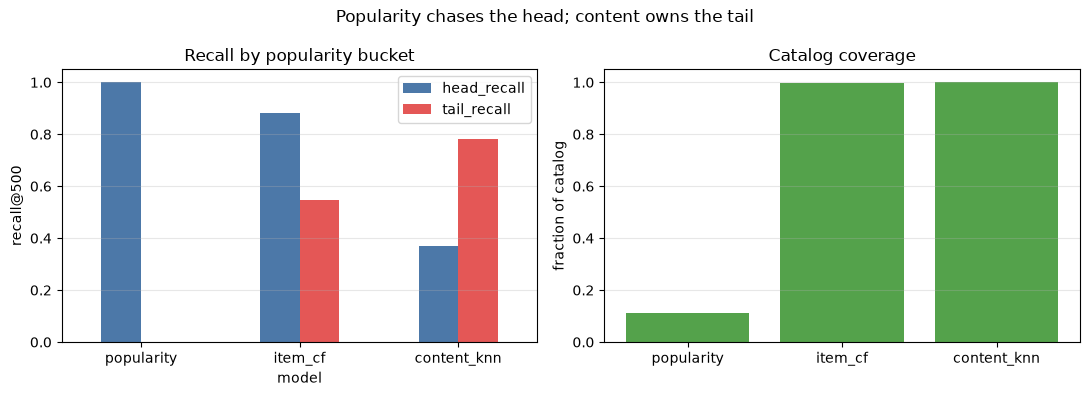

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
cov[['head_recall','tail_recall']].plot.bar(ax=ax1, color=['#4C78A8','#E45756'])
ax1.set_title('Recall by popularity bucket'); ax1.set_ylabel('recall@500')
ax1.set_xticklabels(cov.index, rotation=0); ax1.grid(axis='y', alpha=0.3)
ax2.bar(cov.index, cov.catalog_coverage, color='#54A24B')
ax2.set_title('Catalog coverage'); ax2.set_ylabel('fraction of catalog')
ax2.grid(axis='y', alpha=0.3)
fig.suptitle('Popularity chases the head; content owns the tail')
fig.tight_layout(); fig.savefig(os.path.join(VIZ, 'nb04_coverage.png'), dpi=110)
plt.show()

## The honest conclusion  ([THEORY.md §8](../THEORY.md#8-what-actually-mattered-here))

The two tables above are the whole story, and they point in opposite directions:

- **On accuracy, collaborative filtering wins.** Item-CF and ALS lead every
  seeded scenario; pure content (`content_knn`, ~0.08 overall) sits below even the
  popularity floor. Feature similarity is a weak *ranking* signal because it is
  blind to what people actually put together.
- **On coverage and the tail, content wins outright.** Popularity recovers **0%**
  of the tail and ever surfaces only ~11% of the catalogue; `content_knn` has the
  **best tail recall in the project** and touches **100%** of the catalogue - and,
  because a track has features the day it is created, it is immune to the
  cold-start problem that blinds every CF model to brand-new tracks.

That is the **division of labour**: no single model is best everywhere. The right
system routes big seeds to co-occurrence, the cold start to the title/content
models, and leans on content to serve the catalogue - which is exactly what the
routed and two-stage hybrids in [`REPORT.md`](../REPORT.md) do. And it is why an
offline R-precision leaderboard, read alone, would quietly throw away the model
that makes the product worth using.

See **[`THEORY.md`](../THEORY.md)** for the math behind every model here, and
**[`REPORT.md`](../REPORT.md)** for the full research write-up including the
real-MPD run.